In [ ]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


# Check to see if we're running in Colab (versus local server)

In [ ]:
try:
  from google.colab import drive
  IN_COLAB=True
except:
  IN_COLAB=False

if IN_COLAB:
  print("We're running Colab")

We're running Colab


# Tensorflow with GPU

This notebook provides an introduction to computing on a [GPU](https://cloud.google.com/gpu) in Colab. In this notebook you will connect to a GPU, and then run some basic TensorFlow operations on both the CPU and a GPU, observing the speedup provided by using the GPU.


## Enabling and testing the GPU

First, you'll need to enable GPUs for the notebook:

- Navigate to Edit→Notebook Settings
- select GPU from the Hardware Accelerator drop-down

Next, we'll confirm that we can connect to the GPU with tensorflow:

In [ ]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


## Observe TensorFlow speedup on GPU relative to CPU

This example constructs a typical convolutional neural network layer over a
random image and manually places the resulting ops on either the CPU or the GPU
to compare execution speed.

In [ ]:
import tensorflow as tf
import timeit

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print(
      '\n\nThis error most likely means that this notebook is not '
      'configured to use a GPU.  Change this in Notebook Settings via the '
      'command palette (cmd/ctrl-shift-P) or the Edit menu.\n\n')
  raise SystemError('GPU device not found')

def cpu():
  with tf.device('/cpu:0'):
    random_image_cpu = tf.random.normal((100, 100, 100, 3))
    net_cpu = tf.keras.layers.Conv2D(32, 7)(random_image_cpu)
    return tf.math.reduce_sum(net_cpu)

def gpu():
  with tf.device('/device:GPU:0'):
    random_image_gpu = tf.random.normal((100, 100, 100, 3))
    net_gpu = tf.keras.layers.Conv2D(32, 7)(random_image_gpu)
    return tf.math.reduce_sum(net_gpu)
  
# We run each op once to warm up; see: https://stackoverflow.com/a/45067900
cpu()
gpu()

# Run the op several times.
print('Time (s) to convolve 32x7x7x3 filter over random 100x100x100x3 images '
      '(batch x height x width x channel). Sum of ten runs.')
print('CPU (s):')
cpu_time = timeit.timeit('cpu()', number=10, setup="from __main__ import cpu")
print(cpu_time)
print('GPU (s):')
gpu_time = timeit.timeit('gpu()', number=10, setup="from __main__ import gpu")
print(gpu_time)
print('GPU speedup over CPU: {}x'.format(int(cpu_time/gpu_time)))

Time (s) to convolve 32x7x7x3 filter over random 100x100x100x3 images (batch x height x width x channel). Sum of ten runs.
CPU (s):
0.4042318820000048
GPU (s):
0.03820289700001922
GPU speedup over CPU: 10x


# Start of the code

In [ ]:
import os
# import tensorflow.compat.v1 as tf #import tensorflow as tf by CHS
import tensorflow as tf # by CHS
from tensorflow.keras.utils import to_categorical #from keras.utils import to_categorical by CHS
import glob
import cv2
import numpy as np
import time
import inspect

tf.compat.v1.disable_eager_execution() #by CHS
tf.compat.v1.disable_v2_behavior() #CHS

Instructions for updating:
non-resource variables are not supported in the long term


In [ ]:
ls

sample_data/


In [ ]:
def data_normalizer(data): # by CHS 20221122-24 to make all values into numbers between 0 and 1: from 0 to 255 into between 0 and 1 by dividing 255 to all values
  import numpy as np

  data_normalized = data/(np.max(data)-np.min(data)) # 255 - 0 = 255
  return data_normalized

In [ ]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
# VGG_MEAN = [103.939, 116.779, 123.68]


def load_audio_data(data_normal_flag=True): # by CHS #data_normal_flag=True by CHS 20221122
    #dirs = ['Air Conditioner', 'Car Horn', 'Children Playing', 'Dog Bark'] #21/11/2022 code run experiment
    #dirs = ['Car Horn', 'Children Playing', 'Dog Bark'] #21/11/2022 code run experiment
    dirs = ['Air Conditioner', 'Car Horn', 'Children Playing', 'Dog Bark', 'Drilling', 'Engine Idling', 'Gun Shot', 'Jackhammer', 'Siren', 'Street Music'] 


    data       = [] # by CHS
    lab = []

    i = 0 # The label index in the order above in dirs
    for dir_ in dirs:
        # Python glob. glob() method returns a list of files or folders that matches the path specified in the pathname argument. 
        # This function takes two arguments, namely pathname, and recursive flag. 
        # pathname : Absolute (with full path and the file name) or relative (with UNIX shell-style wildcards)
        files = glob.glob(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/data', dir_,'*.jpg'))     

        files_cnt_each_label = 0
        for file in files:
            data.append(cv2.imread(file, 1))
            files_cnt_each_label += 1

        lab = np.append(lab, np.tile(i, files_cnt_each_label), axis = 0)

        i +=1
    labels = to_categorical(lab) # one-hot conversion # train, test: each 200 개씩 있음
    # data normalization by CHS 20221122 -------
    if data_normal_flag == True:
      data_normalized = data_normalizer(np.array(data))
    # ------------------------------------------
    return np.array(data_normalized), labels # by CHS data-> data_normalized 20221122

In [ ]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
# VGG_MEAN = [103.939, 116.779, 123.68]

# This is also the right version of function confirmed by CHS 20221202 
def load_audio_data_v2(test_fraction=0.3, data_normal_flag=True): 
    """ by CHS : data_normal_flag=True by CHS 20221122
               : test_fraction=0.3     by CHS 20221124
    """

    #dirs = ['Air Conditioner', 'Car Horn', 'Children Playing', 'Dog Bark'] #21/11/2022 code run experiment
    #dirs = ['Car Horn', 'Children Playing', 'Dog Bark'] #21/11/2022 code run experiment
    dirs = ['Air Conditioner', 'Car Horn', 'Children Playing', 'Dog Bark', 'Drilling', 'Engine Idling', 'Gun Shot', 'Jackhammer', 'Siren', 'Street Music'] 

    data       = [] # by CHS
    data_train = []
    data_test  = []
    lab        = [] # by CHS : doesn't have to be numpy 
    lab_train  = [] # by CHS
    lab_test   = [] # by CHS


    i = 0 # The label index in the order above in dirs
    for dir_ in dirs:
        # Python glob. glob() method returns a list of files or folders that matches the path specified in the pathname argument. 
        # This function takes two arguments, namely pathname, and recursive flag. 
        # pathname : Absolute (with full path and the file name) or relative (with UNIX shell-style wildcards)
        files = glob.glob(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/data', dir_,'*.jpg'))     

        files_cnt_each_label = 0
        data_each_label = [] # by CHS
        lab_each_label  = [] # by CHS

        # make data
        for file in files:
            data_each_label.append(cv2.imread(file, 1))
            files_cnt_each_label += 1
                        
        # make labels
        lab_each_label = np.tile(i, files_cnt_each_label)
        # lab_each_label = np.append(lab_each_label, np.tile(i, files_cnt_each_label), axis = 0)

        # split data(of each label) into train_set and test_set by CHS 20221124 ------------------------
        test_data_size_each_label  = int(files_cnt_each_label*test_fraction)
        train_data_size_each_label = files_cnt_each_label - test_data_size_each_label

        data_train.extend(data_each_label[:train_data_size_each_label])
        data_test.extend(data_each_label[train_data_size_each_label:])        
        lab_train.extend(lab_each_label[:train_data_size_each_label])
        lab_test.extend(lab_each_label[train_data_size_each_label:])
        # -------------------------------------------------------------------------------

        i +=1

    labels_train = to_categorical(lab_train) # one-hot conversion 
    labels_test  = to_categorical(lab_test)  # one-hot conversion 

    # data normalization by CHS 20221122 -------
    if data_normal_flag == True:
      data_train_normalized = data_normalizer(np.array(data_train))
      data_test_normalized  = data_normalizer(np.array(data_test))
    # ------------------------------------------
    return np.array(data_train_normalized), labels_train, np.array(data_test_normalized), labels_test  # by CHS data-> data_normalized 20221122

In [ ]:
# a = [1, 2, 3]
# # a = 1
# b = []
# b.extend(a)
# print(b)
# b.extend(a)
# print(b)

In [ ]:
train_data, train_labels, test_data, test_labels = load_audio_data_v2()
train_data_len = len(train_data)
test_data_len  = len(test_data)

In [ ]:
data, labels = load_audio_data()
# train_data_len = len(train_data)
# test_data_len  = len(test_data)

In [ ]:
print(len(train_data))
print(len(test_data))
print(len(train_data)+len(test_data))

6114
2618
8732


In [ ]:
train_labels[-10:]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

In [ ]:
print(np.min(train_data))
print(np.max(train_data))
print(np.min(test_data))
print(np.max(test_data))

0.0
1.0
0.0
1.0


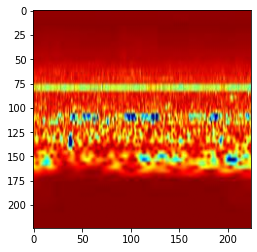

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(data[0])

In [ ]:
class Vgg19():
    def __init__(self, data_len=400, no_labels=10, vgg19_npy_path=None): # data_len=400, no_labels=10,  by CHS
        try:
            # print("ls: ", ls)
            self.data_dict = np.load('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/vgg19.npy', allow_pickle=True, encoding='latin1').item() # , allow_pickle=True by CHS
            # The default allow_pickle was changed for safety reasons. 
            # It reduces the chances of loading something bad from the file. 
            # You have to explicitly allow a pickle load for a file from a trusted source. 
            # Without pickle, the load can only be a safe, numeric (or string) array. – hpaulj  May 4, 2020 at 0:41
        except:
            print("Place vgg19.npy in the same directory as of this notebook.")
            print("You can get it from ")
        self.isTrain = True
        self.epochs = 50
        self.batch_size = 10
        self.data_size = data_len #400
        self.restore = False
        self.decay = 0.99
        self.model_name = 'model'
        self.ckpt_dir = '/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/' + self.model_name + "/checkpoint" 
                                #'./' + self.model_name + "/checkpoint" #'/gdrive/MyDrive/ColabNotebooks/VGG19-Transfer-Learn-master/' by CHS
        self.test_fraction = 0.3 #0.5 # use the half of the train_set aas test_set (by CHS)
        self.no_labels = no_labels #2 #4 #10 # no_labels by CHS 21/11/2022
        
    def model(self):
        """
        load variable from npy to build the VGG

        :param rgb: rgb image [batch, height, width, 3] values scaled [0, 1]
        """

        with tf.compat.v1.variable_scope('Input') as scope:   #.compat.v1 by CHS
            self.rgb = tf.compat.v1.placeholder(name = "Input", shape = [None, 224, 224, 3], dtype = tf.float32)  #[None, 224, 224, 3], dtype = tf.float32) by CHS #.compat.v1 by CHS
            self.labels = tf.compat.v1.placeholder(name = "Labels", shape = [None, self.no_labels], dtype = tf.float32) #4], dtype = tf.float32) #.compat.v1 by CHS
            self.isTrain = tf.compat.v1.placeholder(name = "isTrain", shape = None, dtype = tf.bool) #.compat.v1 by CHS
            self.step = tf.compat.v1.train.get_or_create_global_step() #tf.train.get_or_create_global_step() #.compat.v1 by CHS
            self.lr = tf.compat.v1.placeholder(name = "LR", shape = None, dtype = tf.float32) #.compat.v1 by CHS

        # Convert RGB to BGR
        red, green, blue = tf.split(axis=3, num_or_size_splits=3, value=self.rgb)
        bgr = tf.concat(axis=3, values=[
            blue,  # - VGG_MEAN[0], by CHS
            green, # - VGG_MEAN[1], by CHS
            red,   # - VGG_MEAN[2], by CHS
        ])
        
        self.conv1_1 = self.conv_layer(bgr, "conv1_1")
        self.conv1_2 = self.conv_layer(self.conv1_1, "conv1_2")
        self.pool1 = self.max_pool(self.conv1_2, 'pool1')

        self.conv2_1 = self.conv_layer(self.pool1, "conv2_1")
        self.conv2_2 = self.conv_layer(self.conv2_1, "conv2_2")
        self.pool2 = self.max_pool(self.conv2_2, 'pool2')

        self.conv3_1 = self.conv_layer(self.pool2, "conv3_1")
        self.conv3_2 = self.conv_layer(self.conv3_1, "conv3_2")
        self.conv3_3 = self.conv_layer(self.conv3_2, "conv3_3")
        self.conv3_4 = self.conv_layer(self.conv3_3, "conv3_4")
        self.pool3 = self.max_pool(self.conv3_4, 'pool3')

        self.conv4_1 = self.conv_layer(self.pool3, "conv4_1")
        self.conv4_2 = self.conv_layer(self.conv4_1, "conv4_2")
        self.conv4_3 = self.conv_layer(self.conv4_2, "conv4_3")
        self.conv4_4 = self.conv_layer(self.conv4_3, "conv4_4")
        self.pool4 = self.max_pool(self.conv4_4, 'pool4')

        output = self.pool4

        self.conv5_1 = self.conv_layer(self.pool4, "conv5_1")
        self.conv5_2 = self.conv_layer(self.conv5_1, "conv5_2")
        self.conv5_3 = self.conv_layer(self.conv5_2, "conv5_3")
        self.conv5_4 = self.conv_layer(self.conv5_3, "conv5_4")
        self.pool5 = self.max_pool(self.conv5_4, 'pool5')

        self.fc6 = self.fc_layer(self.pool5, "fc6")
        assert self.fc6.get_shape().as_list()[1:] == [4096]
        self.relu6 = tf.nn.relu(self.fc6)

        self.fc7 = self.fc_layer(self.relu6, "fc7")
        self.relu7 = tf.nn.relu(self.fc7)

        self.logits = self.fc_layer_output(self.relu7, "fc8")
        #self.logits = self.fc_layer_output(self.relu6, "fc7")
    
        with tf.compat.v1.variable_scope("Loss") as scope: # .compat.v1 by CHS
            self.loss = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits = self.logits, labels = self.labels))

        with tf.compat.v1.variable_scope("Accuracy") as scope: # .compat.v1 by CHS

            self.logits_max_args = tf.argmax(self.logits, axis = 1)
            self.labels_max_args = tf.argmax(self.labels, axis = 1) # can retrieve the predictions with this (by CHS)
            self.equal = tf.reduce_sum(tf.cast(tf.equal(self.logits_max_args, self.labels_max_args), tf.float32))
            self.batch_acc = tf.divide(self.equal, tf.cast(tf.shape(self.logits)[0], tf.float32))

        with tf.compat.v1.variable_scope("Optimizer") as scope: #.compat.v1 by CHS

            update_ops = tf.compat.v1.get_collection(tf.compat.v1.GraphKeys.UPDATE_OPS) #.compat.v1 by CHS
            with tf.control_dependencies(update_ops):
                self.optimizer = tf.compat.v1.train.AdamOptimizer(self.lr).minimize(self.loss, self.step) 
                #tf.train.AdamOptimizer(self.lr).minimize(self.loss, self.step) by CHS
            self.saver = tf.compat.v1.train.Saver(max_to_keep = 3) # .compat.v1 by CHS
    
    def avg_pool(self, bottom, name):
        return tf.nn.avg_pool(bottom, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='SAME', name=name)

    def max_pool(self, bottom, name):
        return tf.nn.max_pool(bottom, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='SAME', name=name)

    def conv_layer(self, bottom, name):
        with tf.compat.v1.variable_scope(name): #.compat.v1 by CHS
            filt = self.get_conv_filter(name) # retrieved from the vgg19.npy file (by CHS)

            conv = tf.nn.conv2d(bottom, filt, [1, 1, 1, 1], padding='SAME') # and use the saved weights info from vgg19.npy (by CHS)

            conv_biases = self.get_bias(name)
            bias = tf.nn.bias_add(conv, conv_biases)

            relu = tf.nn.relu(bias)
            return relu

    def fc_layer(self, bottom, name):
        with tf.compat.v1.variable_scope(name): #.compat.v1 by CHS
            shape = bottom.get_shape().as_list()
            dim = 1
            for d in shape[1:]:
                dim *= d
            x = tf.reshape(bottom, [-1, dim])

            weights = self.get_fc_weight(name)
            biases = self.get_bias(name)

            # Fully connected layer. Note that the '+' operation automatically
            # broadcasts the biases.
            fc = tf.nn.bias_add(tf.matmul(x, weights), biases)

            return fc

    def fc_layer_output(self, x, name):
        with tf.compat.v1.variable_scope(name): #.compat.v1 by CHS
            shape = x.get_shape().as_list()
            xavier = tf.initializers.glorot_uniform() #tf.contrib.layers.xavier_initializer() by CHS
            # replaced "tf.contrib.layers.xavier_initializer()" with "tf.initializers.glorot_uniform()" by CHS: tf.contrib is deprecated in Tensorflow 2.x.
            weights = tf.compat.v1.get_variable("Weight", shape=[shape[1], self.no_labels], initializer = xavier, dtype = tf.float32) 
            #.compat.v1 by CHS #changed 4 into self.no_labels 21/11/2022: the output shape needs to be changed by the number of labels
            biases = tf.compat.v1.get_variable("Bias", shape=[self.no_labels], initializer = xavier, dtype = tf.float32) 
            #.compat.v1 by CHS #changed 4 into self.no_labels 21/11/2022: the output shape needs to be changed by the number of labels

            # Fully connected layer. Note that the '+' operation automatically
            # broadcasts the biases.
            fc = tf.nn.bias_add(tf.matmul(x, weights), biases)

            return fc
        
    def get_conv_filter(self, name): # retrieve from vgg19.npy file (by CHS)
        initializer = self.data_dict[name][0]
        return tf.compat.v1.get_variable("Filter", initializer = initializer, dtype = tf.float32) #.compat.v1 by CHS

    def get_bias(self, name): # retrieve from vgg19.npy file (by CHS)
        initializer = self.data_dict[name][1]
        return tf.compat.v1.get_variable("Bias", initializer = initializer, dtype = tf.float32) #.compat.v1 by CHS

    def get_fc_weight(self, name): # retrieve from vgg19.npy file (by CHS)
        initializer = self.data_dict[name][0] # retrieved weights from vgg19.npy (by CHS)
        return tf.compat.v1.get_variable("Weight", initializer = initializer, dtype = tf.float32) #.compat.v1 by CHS
    
    def train(self, shuffle_flag=False): # shuffle_flag=False by CHS 21/11/2022
        # replaced "tf.reset_default_graph()" with: by CHS
        from tensorflow.python.framework import ops
        ops.reset_default_graph() #tf.reset_default_graph() ---------------------------

        print('Loading Data')
        # train_data, train_labels, test_data, test_labels = load_audio_data() # load_audio_data() by CHS
        data, labels = load_audio_data() # load_audio_data() by CHS 20221130    
        print('Data Loaded')
        
        print('Loading Model')
        self.model()
        print('Model Loaded')
        
        if not os.path.exists(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/', self.model_name)):
                            #'/gdrive/MyDrive/ColabNotebooks/VGG19-Transfer-Learn-master/', self.model_name): 
                            # '/gdrive/MyDrive/ColabNotebooks/VGG19-Transfer-Learn-master/', added by CHS 20221125
            # os.mkdir('/gdrive/MyDrive/ColabNotebooks/VGG19-Transfer-Learn-master/',self.model_name)
                   # '/gdrive/MyDrive/ColabNotebooks/VGG19-Transfer-Learn-master/', added by CHS 20221125
            os.mkdir('./' + self.model_name ) #이거좀 다시 고치기, 작동 안하는거 같음 20221125 by CHS
        
        # edit by CHS 20221124, make it alive again 20221130 by CHS ---
        test_data_size = int(self.data_size * self.test_fraction)
        train_data_size = self.data_size - test_data_size
        # # commented out by CHS 20221130  ----------------------------
        # train_data_size = len(train_data)
        # test_data_size  = len(test_data)
        # -------------------------------------------------------------

        train_batches = train_data_size // self.batch_size #the floor division // rounds the result down to the nearest whole number (by CHS): int로 만들어, 남는거 버림
        test_batches = test_data_size // self.batch_size

        #data = ((data/255) * 2) - 1 # [0,255] --> [-1,1]
        
        with tf.compat.v1.Session() as self.sess: # .compat.v1 by CHS
           
            init_op = tf.compat.v1.global_variables_initializer() # .compat.v1 by CHS
            self.sess.run(init_op)
            parameter_count = tf.reduce_sum([tf.reduce_prod(tf.shape(v)) for v in tf.compat.v1.trainable_variables()]) # .compat.v1 by CHS
            
            print('Parameters:', parameter_count.eval()) 
            start = 0
            acc_best = -1
            lr = 0.0001

            # edited by CHS: as train_size and test_size are different ------
            
            # keep track of the original indices of the whole data(= train + test) by CHS 20221130
            original_indices  = np.arange(self.data_size)
            original_data     = data   # 20221205 by CHS
            original_labels   = labels # 20221205 by CHS

            # shuffle the whole data first and then split
            # - No shuffle as we need to compare with other models with the same datasets afterwards, recommended by professor Li Zhang 17/11/2022
            # - But we can still shuffle if we keep track of the original indices of the whole data(= train + test) (by CHS) 20221130
            if shuffle_flag == True:  
              #random seed to be added here by CHS 20221201
                        
              shuffled_ind  = np.random.permutation(self.data_size)                
              permuted_indices   = original_indices[shuffled_ind]
              print(f"permuted_indices : {permuted_indices}") # by CHS
              # 20221130 added by CHS   ---------
              data   = data[permuted_indices]
              labels = labels[permuted_indices]
              # ---------------------------------

            # split 
            #   - split data and labels by CHS : included again by CHS 20221130
            train_data   = np.copy(data[0:train_data_size])
            test_data    = np.copy(data[train_data_size:])
            train_labels = np.copy(labels[0:train_data_size])
            test_labels  = np.copy(labels[train_data_size:])           
            #   - split indices added by CHS 20221130
            if shuffle_flag == True:             
              train_indices  = permuted_indices[0:train_data_size] 
              test_indices   = permuted_indices[train_data_size:]        
            else:
              train_indices  = original_indices[0:train_data_size] 
              test_indices   = original_indices[train_data_size:]                   

            # commented out by CHS 20221130 (no need to shuffle again as we already shuffled above)
            # # # No shuffle as we need to compare with other models with the same datasets afterwards, recommended by professor Li Zhang 17/11/2022
            # # # train_indices, test_indices: set up lists of indices by CHS
            # # # when shuffle_flag == True, shuffle again here, train_set and test_set, separately. by CHS
            # if shuffle_flag == True:                 
            #   train_indices  = np.copy(np.random.permutation(train_data_size)) 
            #   test_indices   = np.copy(np.random.permutation(test_data_size))   
            # else: 
            #   train_indices  = np.arange(train_data_size) 
            #   test_indices   = np.arange(test_data_size)                      

            # # in case the_data_size == the_test_size: (by CHS) We won't use this 3 lines as we have different sizes of train and test datasets. Oct/2022
            # data_perm = np.random.permutation(train_data_size)
            # train_perm = data_perm
            # test_perm = np.copy(data_perm)                    -------------

            print('Training commences from epoch ', start)

            for i in range(start, self.epochs):
                
                count = 0
                count_test = 0
                avg_loss = 0

                # no need 20221201 by CHS
                # # # No shuffle as we need to compare with other models with the same datasets afterwards, recommended by professor Li Zhang 17/11/2022
                # # # shuffle one more time for train_data
                # if shuffle_flag == True:                      
                #   shuffle = np.random.permutation(train_data_size)
                #   train_indices = train_indices[shuffle] #train_perm = train_perm[shuffle] (by CHS)
                #   print(f"train_indices : {train_indices }") # by CHS

                if i+1 == 50:
                    lr = lr/10
                
                for j in range(train_batches): #train_batches: train_data에서 뒤에 남는 몇개 뺀 가득찬 batch들의 개수, int 개수에 대해 batch수 만큼 loop돌아 
                    
                    begin = time.time()
                    print("j: ", j) # by CHS
                    print(f"What is the size of train_data?: {np.size(train_data)}")
                    if j != train_batches-1 : # i.e.즉 마지막 batch가 아닐 경우
                        current_batch = np.arange(j*self.batch_size, (j+1)*self.batch_size) #[j*self.batch_size : (j+1)*self.batch_size] #train_perm[j*self.batch_size : (j+1)*self.batch_size] (by CHS)
                        print(f"current_batch: {current_batch}")# by CHS
                        # print(f"train_data[current_batch[0]]: {train_data[current_batch[0]]}")# by CHS
                        current_batch_real_indices_from_the_whole_dataset = train_indices[j*self.batch_size : (j+1)*self.batch_size]
                        print(f"current_batch_real_indices_from_the_whole_dataset: {current_batch_real_indices_from_the_whole_dataset}")# by CHS
                        x = train_data[current_batch]   # train_data size == 0 ==> the problem at the moment by CHS
                        y = train_labels[current_batch] 
                        # current_batch = train_indices[j*self.batch_size : (j+1)*self.batch_size] #train_perm[j*self.batch_size : (j+1)*self.batch_size] (by CHS)
                        # print(f"current_batch: {current_batch}")# by CHS
                        # print(f"train data[current_batch[0]]: {data[current_batch[0]]}")# by CHS
                        # x = data[current_batch]   #from train_data   -> data   editied by CHS 20221201 # train_data size == 0 ==> the problem at the moment by CHS
                        # y = labels[current_batch] #from train_labels -> labels editied by CHS 20221201
                    else: # i.e.즉 마지막 batch일 경우: 정수로 떨어진 batch제외 그 이후 남는 떨거지들을 그냥 마지막 batch에 껴넣어서 돌린다. 그래도 상관은 없음 (by CHS)
                        current_batch = np.arange(j*self.batch_size, len(train_data)) #[j*self.batch_size: ] # filled in this line as it disappeared (by CHS) 20221129
                        x = train_data[current_batch]   
                        y = train_labels[current_batch]                     
                        # current_batch = train_indices[j*self.batch_size: ] # filled in this line as it disappeared (by CHS) 20221129
                        # x = data[current_batch]   #from train_data   -> data   editied by CHS 20221201
                        # y = labels[current_batch] #from train_labels -> labels editied by CHS 20221201

                    feed_train = {self.rgb: x, self.labels: y, self.lr: lr} #self.rgb에 x넣고, self.labels에 y넣고, self.lr에 lr넣고 (by CHS)
                    
                    _, eq, loss = self.sess.run([self.optimizer, self.equal, self.loss], feed_dict = feed_train) # 넣고 드디어 돌리는 부분
                    count += eq
                    avg_loss += loss
                    
                    line = 'Batch: %d Batch Accuracy: %.4f Loss: %.4f Time/Batch: %.4f' %(j, eq/len(current_batch), float(loss), time.time() - begin)
                    print(line, end ='\r')

                # save predictions after training by CHS 20221129-1207 -----
                x_data = train_data
                y_data = train_labels                
                feed_trainset = {self.rgb: x_data, self.labels: y_data}
                predictions_train = self.sess.run(self.labels_max_args, feed_dict = feed_trainset) 
                print("Epoch: %d" %(i), " After training: Predictions of trainset: \n", predictions_train) 

                # - save train_indices, test_indices, predictions, real labels by CHS 20221201 to keep track of dataset indices                     

                # results = f"Epoch: {i} After training: Predictions of trainset: \n{str(predictions_train)}\n"
                # print(results)

                from datetime import date
                from time import gmtime
                results = ""
                with open(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/',self.model_name,'predictions_train_'+str(date.today())+'.txt'), 'a') as f : 
                    for i_p in range(len(predictions_train)):
                      result = "Epoch:"+str(i)+",\ttrain_indices["+str(i_p)+"]: real index of the whole data "+str(train_indices[i_p])+",\tprediction:"+ str(predictions_train[i_p])+\
                               ",\ttrain_labels:"+str(np.argmax(train_labels[i_p]))+"\n"
                      # print(result)
                      results += result
                    f.write(results)
                    # for pred_train in predictions_train:
                    #   f.write(str(pred_train)+"\n")                 
                f.close()             

                # ----------------------------------------------------------


                for j in range(test_batches):
                    
                    print('======================Testing====================', end = '\r')
                    begin = time.time()
                    
                    if j != test_batches-1 : 
                        current_batch = np.arange(j*self.batch_size, (j+1)*self.batch_size) #[j*self.batch_size: (j+1)*self.batch_size] #test_perm[j*self.batch_size: (j+1)*self.batch_size] (by CHS)
                        x = test_data[current_batch]   
                        y = test_labels[current_batch] 
                        # current_batch = test_indices[j*self.batch_size: (j+1)*self.batch_size] #test_perm[j*self.batch_size: (j+1)*self.batch_size] (by CHS)
                        # x = data[current_batch]   #from test_data    -> data   editied by CHS 20221201 
                        # y = labels[current_batch] #from test_labels  -> labels editied by CHS 20221201
                    else:
                        current_batch = np.arange(j*self.batch_size, len(test_data)) #test_perm[j*self.batch_size: ] (by CHS)
                        x = test_data[current_batch]   
                        y = test_labels[current_batch]                     
                        # current_batch = test_indices[j*self.batch_size: ] #test_perm[j*self.batch_size: ] (by CHS)
                        # x = data[current_batch]   #from test_data    -> data   editied by CHS 20221201
                        # y = labels[current_batch] #from test_labels  -> labels editied by CHS 20221201

                    feed_test = {self.rgb: x, self.labels: y}
                    eq = self.sess.run(self.equal, feed_dict = feed_test)
                    #print(eq)
                    count_test += eq
                

                accuracy = count / train_data_size
                accuracy_test = count_test / test_data_size
                avg_loss = avg_loss / train_batches

                line = "Epoch: %d Train Acc: %.6f Test Acc: %.6f Average Loss/Batch: %.6f" %(i,accuracy,accuracy_test,avg_loss)
                print(line)

                with open(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/',self.model_name,'logs_'+str(date.today())+'.txt'), 'a') as f : 
                                # path '/gdrive/MyDrive/ColabNotebooks/VGG19-Transfer-Learn-master/',added by CHS 20221124
                    line += '\n'
                    f.write(line)
           

                # save predictions after training by CHS 20221129-1207 -----
                x_data = test_data
                y_data = test_labels  
                feed_testset = {self.rgb: x_data, self.labels: y_data}
                predictions_test = self.sess.run(self.labels_max_args, feed_dict = feed_testset) 
                print("Epoch: %d" %(i), " After training: Predictions of testset: \n", predictions_test) 

                # - save train_indices, test_indices, predictions, real labels by CHS 20221201 to keep track of dataset indices                     

                # results = f"Epoch: {i} After training: Predictions of trainset: \n{str(predictions_train)}\n"
                # print(results)

                from datetime import date
                from time import gmtime
                results = ""
                with open(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/',self.model_name,'predictions_test_'+str(date.today())+'.txt'), 'a') as f : 
                    for i_p in range(len(predictions_test)):
                      result = "Epoch:"+str(i)+",\ttest_indices["+str(i_p)+"]: real index of the whole data "+str(test_indices[i_p])+",\tprediction:"+ str(predictions_test[i_p])+\
                               ",\ttest_labels:"+str(np.argmax(test_labels[i_p]))+"\n"
                      # print(result)
                      results += result
                    f.write(results)
                    # for pred_train in predictions_train:
                    #   f.write(str(pred_train)+"\n")                 
                f.close()             

                # ----------------------------------------------------------



                # save model by CHS 20221201 -----


                # --------------------------------

In [ ]:
net = Vgg19(data_len=len(data), no_labels=10) # data_len=len(data), no_labels=3, by CHS
net.train(shuffle_flag=True)

Streaming output truncated to the last 5000 lines.
What is the size of train_data?: 920177664
current_batch: [5850 5851 5852 5853 5854 5855 5856 5857 5858 5859]
current_batch_real_indices_from_the_whole_dataset: [1204 3989 3983 7548 4376 8587  604 5684 2597 3836]
j:  586
What is the size of train_data?: 920177664
current_batch: [5860 5861 5862 5863 5864 5865 5866 5867 5868 5869]
current_batch_real_indices_from_the_whole_dataset: [6017  523 6923 7033 4921 5037  944 4810 6744 1910]
j:  587
What is the size of train_data?: 920177664
current_batch: [5870 5871 5872 5873 5874 5875 5876 5877 5878 5879]
current_batch_real_indices_from_the_whole_dataset: [7254 2519 4919 5138 4446  314 1732 2708 6007 5118]
j:  588
What is the size of train_data?: 920177664
current_batch: [5880 5881 5882 5883 5884 5885 5886 5887 5888 5889]
current_batch_real_indices_from_the_whole_dataset: [ 514 7763 1632 7564 6633 6026  814 2218 4738 2877]
j:  589
What is the size of train_data?: 920177664
current_batch: [5890 5

In [ ]:
# train_data_size = 10
# train_indices = np.arange(train_data_size)#[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
# print(train_indices)
# shuffle = np.random.permutation(train_data_size)
# print(shuffle)
# train_indices = train_indices[shuffle]
# print(train_indices)